In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ['ISF.L', 'VWRL.L', 'IGLT.L', 'IBTM.L', 'INXG.L', 'SGLN.L', 'SLXX.L', 'IUKP.L']

data = yf.download(tickers, start='2020-01-01', end='2025-01-01')['Close']

data.head()

[*********************100%***********************]  8 of 8 completed


Ticker,IBTM.L,IGLT.L,INXG.L,ISF.L,IUKP.L,SGLN.L,SLXX.L,VWRL.L
Date,,,,,,,,
2020-01-02,129.042419,11.622167,15.791017,747.732056,665.819580,2271.25,121.932076,64.181473
2020-01-03,130.370453,11.714336,15.954245,750.326111,664.372803,2316.00,122.366219,64.239952
2020-01-06,129.635452,11.649397,15.856646,745.137756,655.641663,2323.00,122.245613,63.767586
2020-01-07,130.086472,11.655682,15.766618,745.038025,657.238220,2341.00,122.205437,64.176964
2020-01-08,130.353760,11.626355,15.730437,744.838440,648.656494,2343.00,122.048660,64.370422


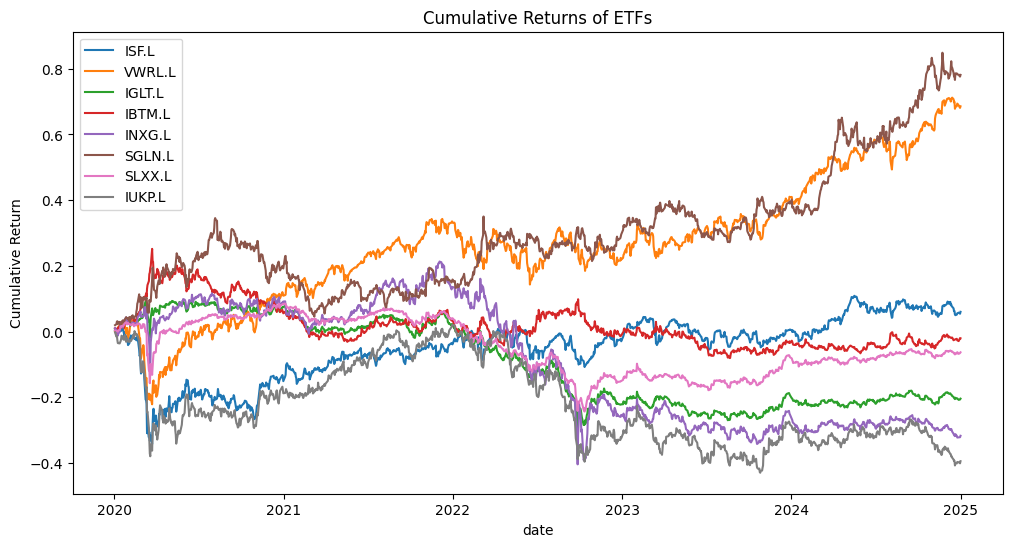

In [9]:
data = data.dropna()
returns = data.pct_change().dropna()
cumulative_returns = (1 + returns).cumprod() - 1
cumulative_returns.head()
plt.figure(figsize=(12,6))
for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)
plt.title('Cumulative Returns of ETFs')
plt.xlabel('date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.savefig('outputs/cumulative_returns.png', dpi=300, bbox_inches='tight')

In [6]:
mean_returns = returns.mean()
## print(mean_returns)
annual_mean_returns = mean_returns * 252
## print(annual_mean_returns)
cov_matrix = returns.cov()
## print(cov_matrix)
corr_matrix = returns.corr()
##print(corr_matrix)

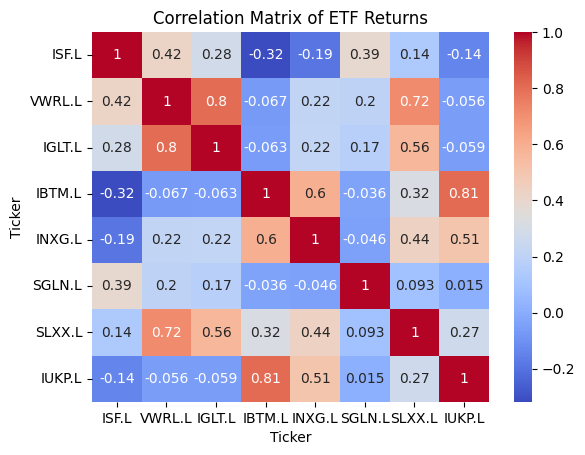

In [8]:
import seaborn as sns

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', xticklabels=tickers, yticklabels=tickers)
plt.title('Correlation Matrix of ETF Returns')
plt.savefig('outputs/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
weights = np.array([1/len(tickers)] * len(tickers))

def portfolio_perf(weights, mean_returns, cov_matrix):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix * 252, weights))
    portfolio_volatility = np.sqrt(portfolio_variance)
    sharpe_ratio = (portfolio_return -rfr) / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio

portfolio_return, portfolio_volatility, sharpe_ratio = portfolio_perf(weights, annual_mean_returns, cov_matrix)

rfr = 0.04
## UK short term gov bond yield

print(f"Return: {portfolio_return:.4f}")
print(f"Volatility: {portfolio_volatility:.4f}")
print(f"Sharpe: {sharpe_ratio:.4f}")


Return: 0.0122
Volatility: 0.0887
Sharpe: -0.3136


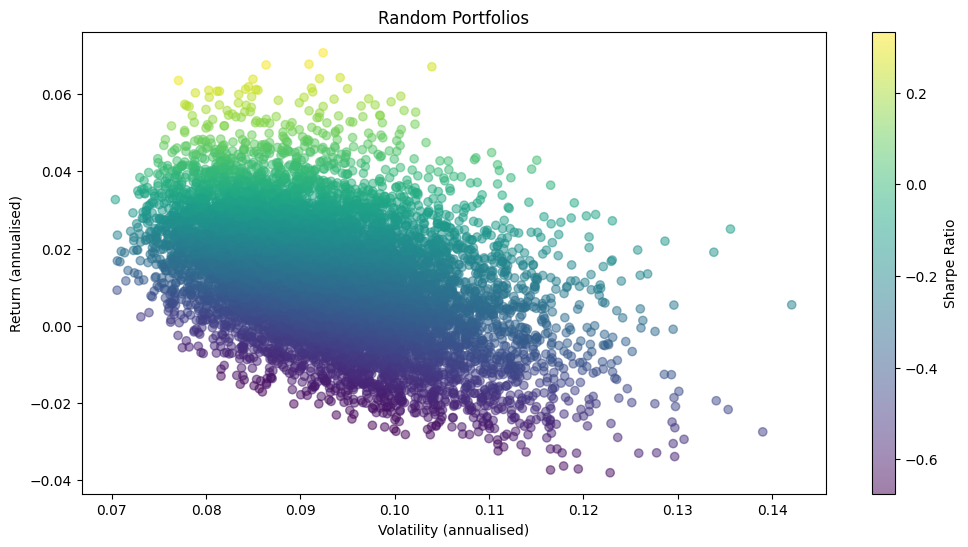

In [31]:
returns_list = []
vols_list = []
sharpes_list = []
weights_list = []

for i in range(10000):
    weights = np.random.random(len(tickers))
    norm_weights = weights / np.sum(weights)
    ret, vol, sharpe = portfolio_perf(norm_weights, annual_mean_returns, cov_matrix)
    returns_list.append(ret)
    vols_list.append(vol)
    sharpes_list.append(sharpe)
    weights_list.append(norm_weights)

returns_arr = np.array(returns_list)
vols_arr = np.array(vols_list)
sharpes_arr = np.array(sharpes_list)

plt.figure(figsize=(12,6))
plt.scatter(vols_arr, returns_arr, c=sharpes_arr, cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (annualised)')
plt.ylabel('Return (annualised)')
plt.title('Random Portfolios')
plt.savefig('outputs/random_portfolios.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
best_rndportfolio = np.argmax(sharpes_arr)
print(f"Best random Sharpe: {sharpes_arr[best_rndportfolio]:.4f}")
print(f"Return: {returns_arr[best_rndportfolio]:.4f}")
print(f"Volatility: {vols_arr[best_rndportfolio]:.4f}")

print("Weights:")
for ticker, w in zip(tickers, weights_list[best_rndportfolio]):
    print(f"  {ticker}: {w:.4f}")

Best random Sharpe: 0.3328
Return: 0.0708
Volatility: 0.0924
Weights:
  ISF.L: 0.0098
  VWRL.L: 0.0351
  IGLT.L: 0.1650
  IBTM.L: 0.0075
  INXG.L: 0.0202
  SGLN.L: 0.3656
  SLXX.L: 0.0808
  IUKP.L: 0.3160
